# Data Acquisition & Exploratory Data Analysis (EDA)



## 1. Data Acquisition

This section acquires the Heart Disease Cleveland dataset from the UCI Machine Learning Repository, assigns meaningful column names, and stores a local copy of the raw dataset. The objective is to ensure data availability, reproducibility, and a consistent starting point for subsequent data exploration and preprocessing.

In [2]:
from pathlib import Path
import pandas as pd

# URL of the Heart Disease Cleveland dataset from the UCI Machine Learning Repository
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Assign meaningful column names to the dataset
COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Create the directory to store the raw dataset (if it doesn't already exist)
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Define the path where the downloaded dataset will be saved
raw_file = RAW_DIR / "heart_cleveland.csv"

# Download the dataset from the UCI repository and load it into a pandas DataFrame
df = pd.read_csv(DATA_URL, header=None, names=COLUMN_NAMES)

# Save a local copy of the raw dataset as a CSV file
df.to_csv(raw_file, index=False)

# Display basic information to verify that the dataset was downloaded successfully
print(f"Dataset downloaded and saved to: {raw_file}")
print(f"Dataset Shape: {df.shape}")

# Display the first five records of the dataset
df.head()

Dataset downloaded and saved to: data/raw/heart_cleveland.csv
Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Understanding

This section presents an overview of the dataset, including its structure, feature types, and statistical summary. The objective is to identify potential data quality issues before data preprocessing and model development.

In [4]:
# Display information about the dataset, including column names, data types, and non-null value counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [5]:
# Generate descriptive statistics for the numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [6]:
# Check for missing values represented by '?'
(df == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 3. Data Cleaning

This section improves the quality of the dataset by handling missing values, correcting data types, and preparing the target variable for binary classification. These preprocessing steps ensure that the dataset is suitable for exploratory data analysis and machine learning model development.

In [7]:
import numpy as np

# Replace missing value placeholders ('?') with NaN
df.replace("?", np.nan, inplace=True)

# Verify missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
# Convert 'ca' and 'thal' columns to numeric data types
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

# Verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [10]:
# Impute missing values in 'ca' and 'thal' using the median
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Verify that all missing values have been handled
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [11]:
# Convert the target variable into a binary classification label
# 0 -> No heart disease
# 1, 2, 3, 4 -> Heart disease
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# Verify the updated class distribution
df["target"].value_counts()

,count
target,
0,164
1,139


## 4. Exploratory Data Analysis (EDA)

This section explores the dataset through visualizations to understand the distribution of features, identify patterns and relationships, detect potential outliers, and examine the distribution of the target variable. The insights obtained from this analysis support feature engineering and model development.

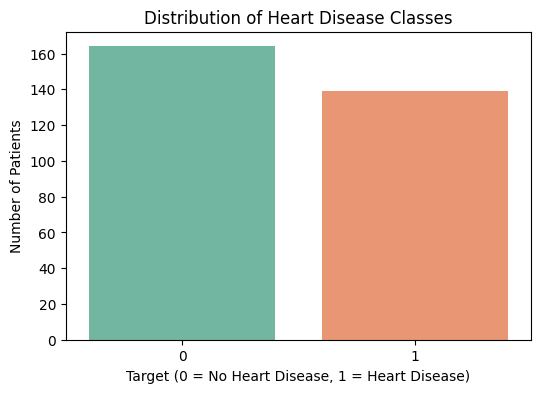

target
0    164
1    139
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target", hue="target", palette="Set2", legend=False)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Number of Patients")

plt.show()

# Display the class counts
print(df["target"].value_counts())

**Observation:**

- The dataset contains patients with and without heart disease.
- The class distribution is relatively balanced, indicating that no severe class imbalance is present.
- A balanced target distribution is beneficial for training and evaluating classification models.

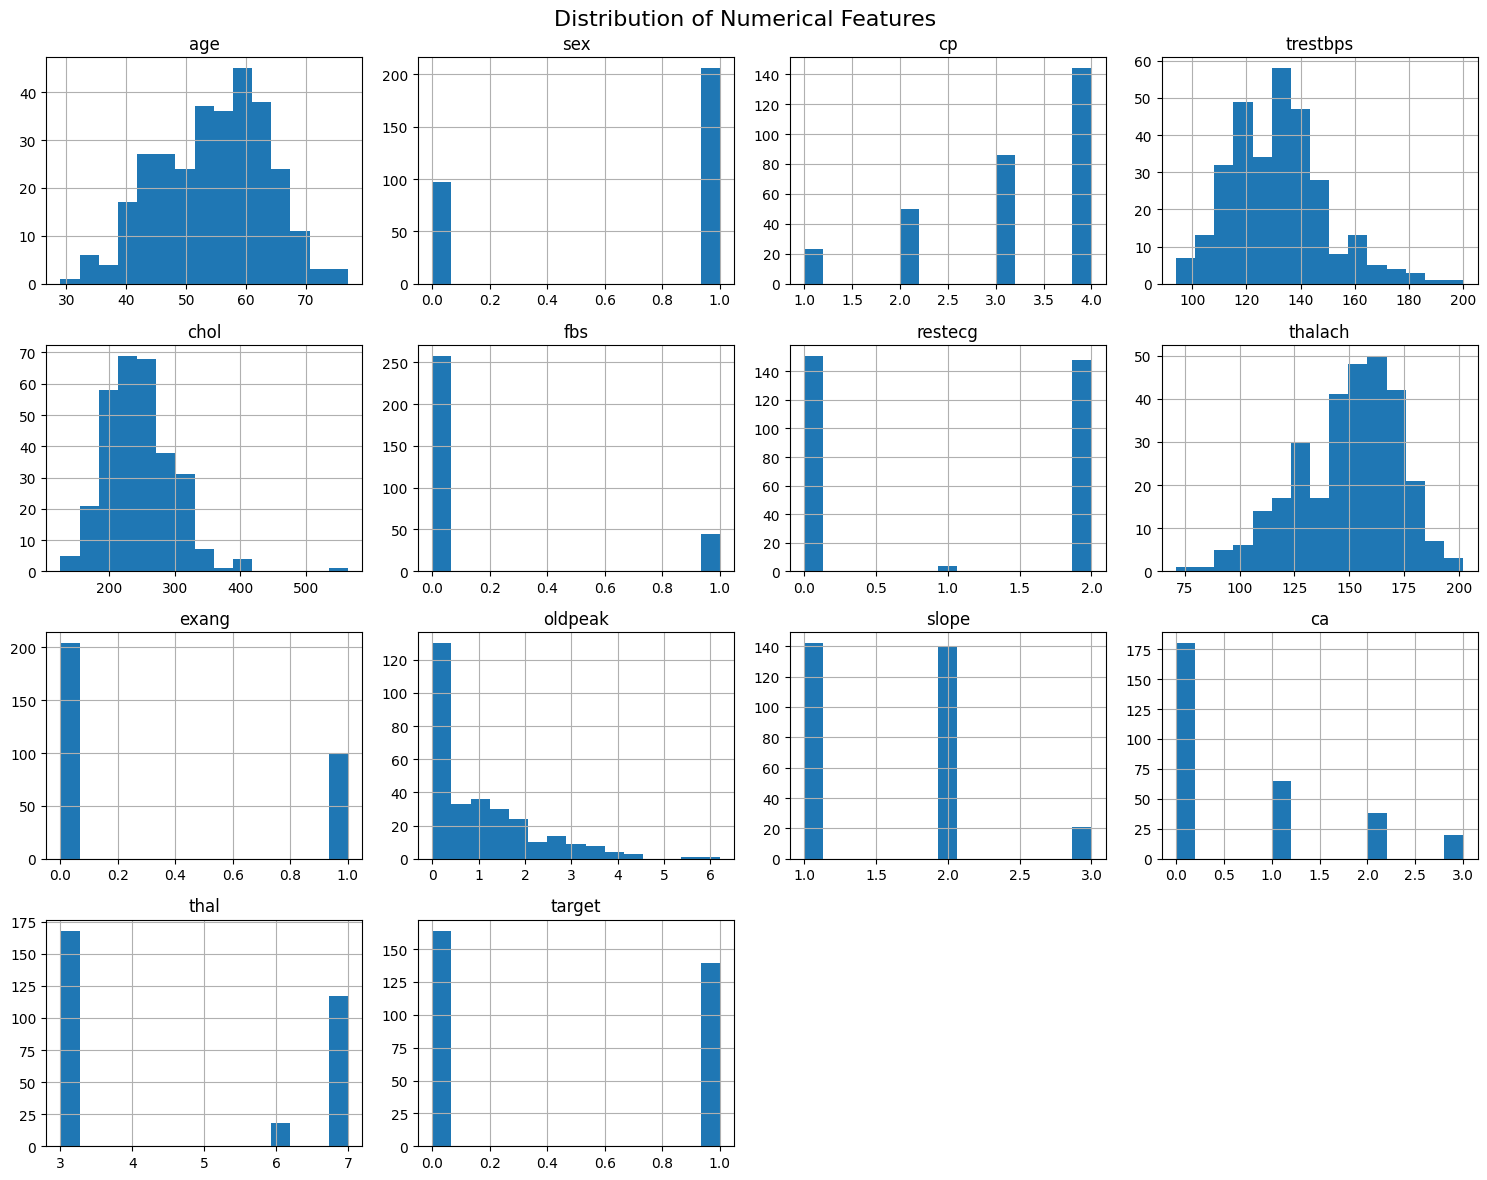

In [14]:
# Plot histograms to understand the distribution of numerical features
df.hist(figsize=(15, 12), bins=15)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

plt.show()

**Observation:**

- The histograms provide an overview of the distribution of each feature.
- Several features exhibit discrete distributions, while others are continuous with varying degrees of skewness.
- These distributions help identify potential outliers and determine whether feature scaling or transformation may be beneficial during model development.

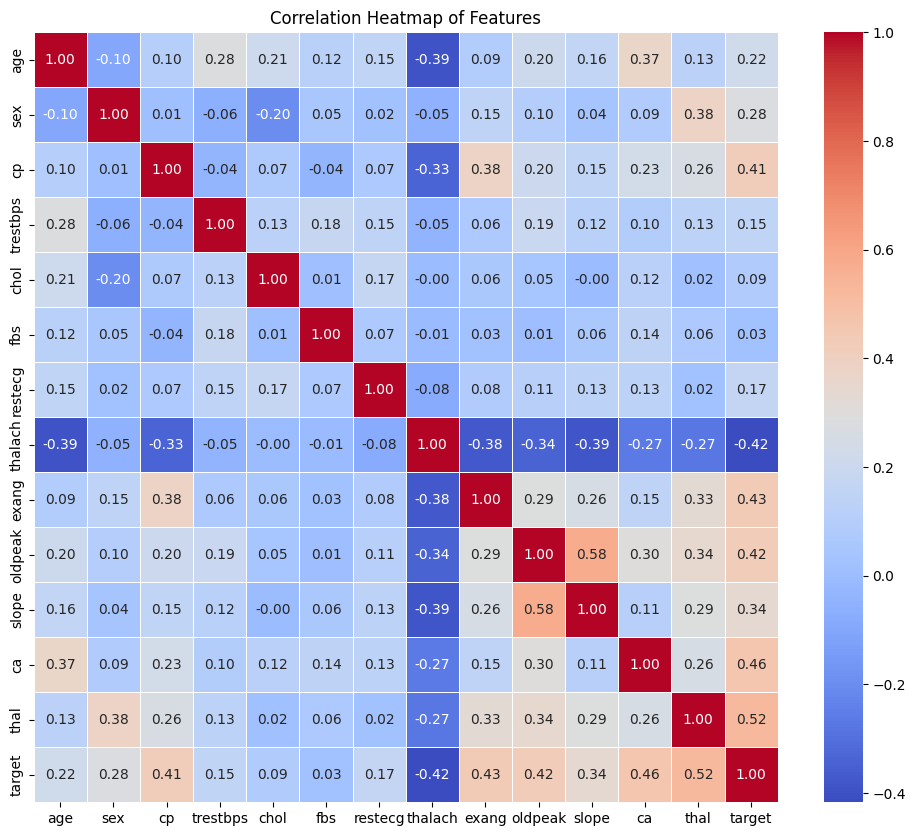

In [15]:
# Compute the correlation matrix for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features")
plt.show()

**Observation:**

- The correlation heatmap illustrates the strength and direction of linear relationships between the features.
- Most features exhibit weak to moderate correlations, indicating limited multicollinearity.
- Features with stronger correlations to the target variable may contribute more significantly to the predictive performance of the classification models.

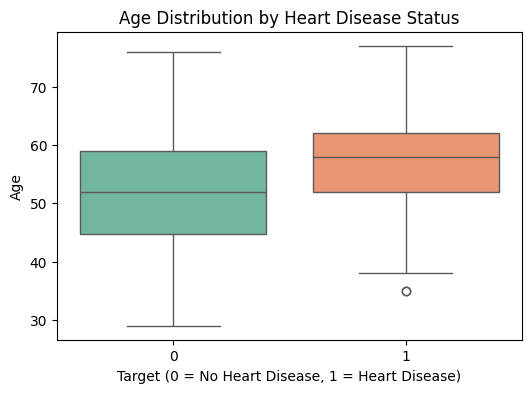

In [16]:
# Visualize the relationship between age and heart disease
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="age", hue="target", palette="Set2", legend=False)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Age")

plt.show()

- The boxplot compares the age distribution of patients with and without heart disease.
- Differences in the median and spread of age may indicate whether age is associated with the occurrence of heart disease.

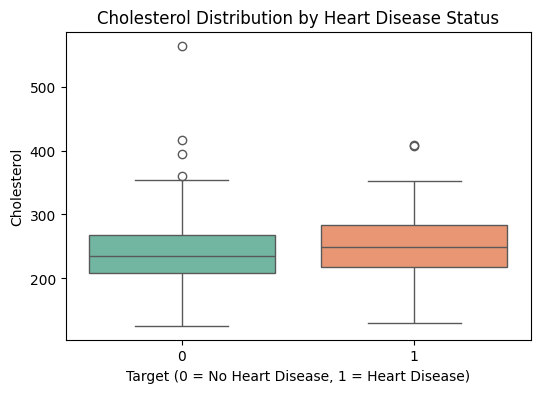

In [17]:
# Visualize the relationship between cholesterol level and heart disease
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="chol", hue="target", palette="Set2", legend=False)

plt.title("Cholesterol Distribution by Heart Disease Status")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Cholesterol")

plt.show()

- The cholesterol distribution is compared across both target classes.
- Variations in the median and spread may indicate whether cholesterol levels differ between patients with and without heart disease.

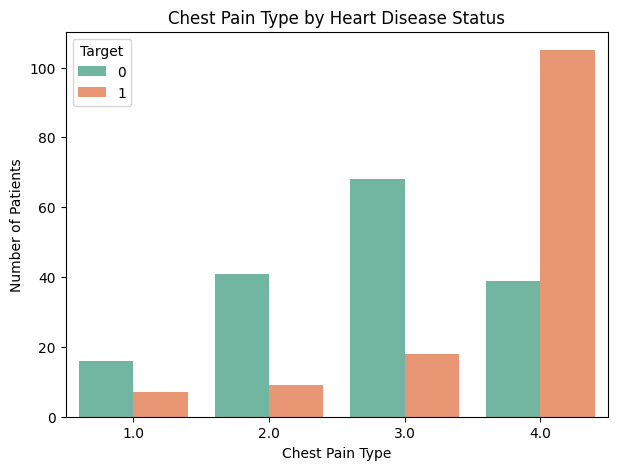

In [18]:
# Visualize the relationship between chest pain type and heart disease
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="cp", hue="target", palette="Set2")

plt.title("Chest Pain Type by Heart Disease Status")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.legend(title="Target")

plt.show()

- The distribution of heart disease cases varies across different chest pain types.
- Certain chest pain categories appear more frequently among patients diagnosed with heart disease, suggesting that this feature may be an important predictor.

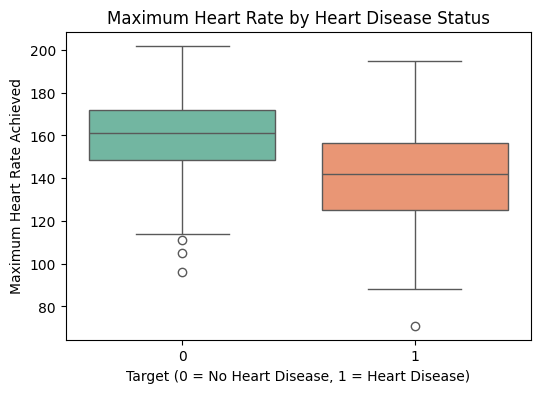

In [19]:
# Visualize the relationship between maximum heart rate and heart disease
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="target", y="thalach", hue="target", palette="Set2", legend=False)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Maximum Heart Rate Achieved")

plt.show()

- The maximum heart rate achieved is compared across the two target classes.
- Differences in the distribution may indicate that this feature contributes to distinguishing patients with and without heart disease.

### EDA Summary

The exploratory data analysis indicates that the dataset is of good quality after preprocessing, with all missing values successfully handled. Several features exhibit meaningful relationships with the target variable, supporting their use for predictive modeling. The dataset also shows a relatively balanced class distribution, making it suitable for training and evaluating classification models.

# Feature Engineering & Model Development

## 5. Feature Engineering

This section prepares the dataset for machine learning by separating the input features and target variable, splitting the data into training and testing sets, and applying the necessary preprocessing techniques. These steps ensure that the data is appropriately transformed for model training and evaluation.

In [21]:
# Separate the input features and target variable
X = df.drop("target", axis=1)
y = df["target"]

# Display the shape of the feature matrix and target vector
print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

Feature Matrix Shape: (303, 13)
Target Vector Shape: (303,)


In [22]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of the training and testing datasets
print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")
print(f"Training Target: {y_train.shape}")
print(f"Testing Target: {y_test.shape}")

Training Features: (242, 13)
Testing Features: (61, 13)
Training Target: (242,)
Testing Target: (61,)


In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 6. Model Development

This section develops and evaluates multiple classification models to predict the presence of heart disease based on patient health attributes. The objective is to compare the performance of different algorithms and identify the most suitable model for the prediction task.

### Logistic Regression

Logistic Regression is selected as the baseline classification model due to its simplicity, interpretability, and effectiveness for binary classification problems. It serves as a reference model for evaluating predictive performance before comparing it with more complex algorithms. The model is trained using the preprocessed training data and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC metrics.

In [24]:
from sklearn.linear_model import LogisticRegression

# Train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### Model Performance

The performance of the Logistic Regression model is assessed using standard classification metrics. These metrics provide a comprehensive evaluation of the model's predictive capability and serve as a baseline for comparison with subsequent classification models.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Generate predictions on the test dataset
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Store the evaluation metrics
lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
}

# Display the evaluation metrics
for metric, value in lr_results.items():
    print(f"{metric:<10}: {value:.4f}")

Accuracy  : 0.8689
Precision : 0.8125
Recall    : 0.9286
F1-Score  : 0.8667
ROC-AUC   : 0.9513


#### Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's classification performance by comparing the predicted labels with the actual labels. It helps identify correctly classified instances as well as false positives and false negatives.

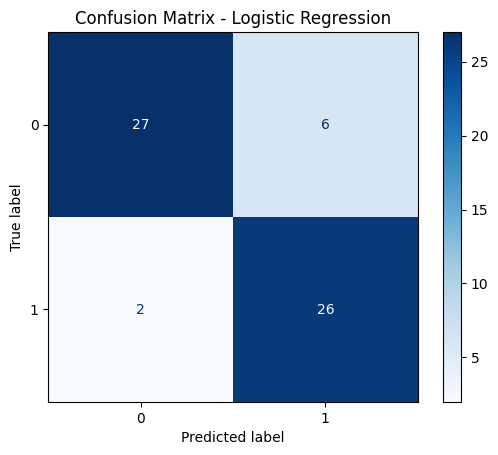

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### Classification Report

The classification report summarizes the model's performance by presenting precision, recall, F1-score, and support for each class.

In [29]:
from sklearn.metrics import classification_report

# Display the classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



#### Receiver Operating Characteristic (ROC) Curve

The ROC curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds. The Area Under the Curve (ROC-AUC) provides an overall measure of the model's ability to distinguish between the two classes.

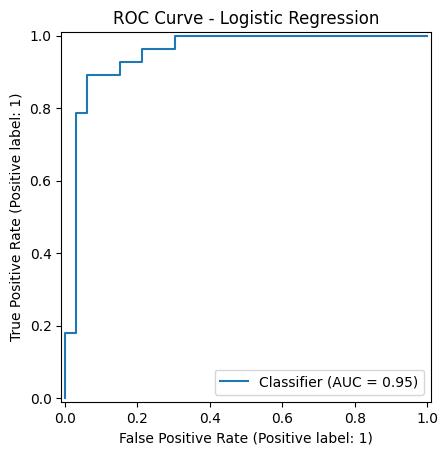

In [30]:
from sklearn.metrics import RocCurveDisplay

# Display the ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_lr)

plt.title("ROC Curve - Logistic Regression")
plt.show()

#### Cross-Validation

Cross-validation is performed to evaluate the generalization capability of the Logistic Regression model across multiple data splits. A 5-fold cross-validation strategy is used to obtain a more reliable estimate of the model's performance and reduce the risk of evaluation bias resulting from a single train-test split.

In [38]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Cross-Validation Scores: {lr_cv_scores}")
print(f"Mean Accuracy: {lr_cv_scores.mean():.4f}")
print(f"Standard Deviation: {lr_cv_scores.std():.4f}")

Cross-Validation Scores: [0.91836735 0.7755102  0.83333333 0.83333333 0.77083333]
Mean Accuracy: 0.8263
Standard Deviation: 0.0534


### Random Forest

Random Forest is selected as the second classification model due to its ability to capture complex, non-linear relationships and its robustness to overfitting. The model is trained using the same dataset and evaluated using the same performance metrics to enable a fair comparison with the baseline Logistic Regression model.

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=42
)

# Train the model using the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### Model Performance

The performance of the Random Forest model is assessed using standard classification metrics. These metrics provide a comprehensive evaluation of the model's predictive capability and enable a direct comparison with the baseline Logistic Regression model.

In [32]:
# Generate predictions on the test dataset
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Store the evaluation metrics
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

# Display the evaluation metrics
for metric, value in rf_results.items():
    print(f"{metric:<10}: {value:.4f}")

Accuracy  : 0.8852
Precision : 0.8387
Recall    : 0.9286
F1-Score  : 0.8814
ROC-AUC   : 0.9518


#### Confusion Matrix

The confusion matrix provides a detailed breakdown of the Random Forest model's classification performance by comparing the predicted labels with the actual labels. It highlights the number of correctly and incorrectly classified instances for each class.

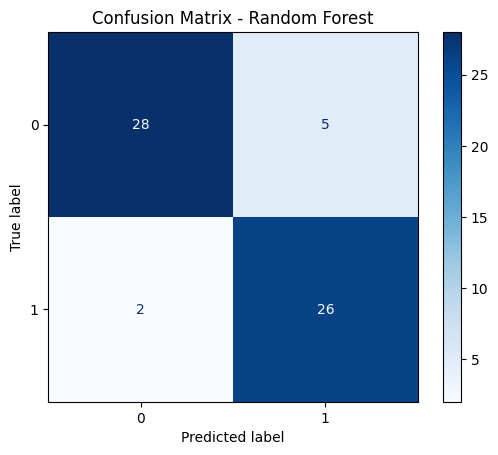

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

#### Classification Report

The classification report summarizes the performance of the Random Forest model by presenting precision, recall, F1-score, and support for each class.

In [34]:
from sklearn.metrics import classification_report

# Display the classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



#### Receiver Operating Characteristic (ROC) Curve

The ROC curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds. The Area Under the Curve (ROC-AUC) provides an overall measure of the Random Forest model's ability to distinguish between the two classes.

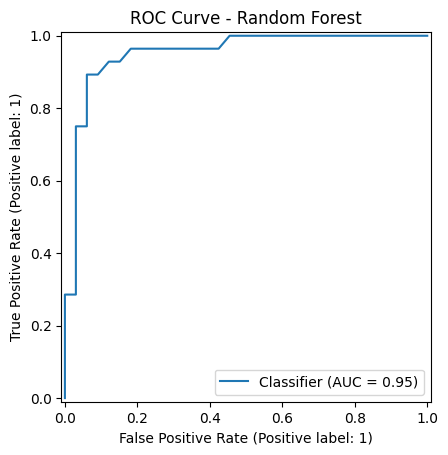

In [35]:
from sklearn.metrics import RocCurveDisplay

# Display the ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_rf)

plt.title("ROC Curve - Random Forest")
plt.show()

#### Cross-Validation

Cross-validation is performed to evaluate the generalization capability of the Random Forest model across multiple data splits. A 5-fold cross-validation strategy is used to obtain a more reliable estimate of the model's performance and assess its consistency across different subsets of the training data.

In [39]:
# Perform 5-fold cross-validation for Random Forest
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"Cross-Validation Scores: {rf_cv_scores}")
print(f"Mean Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")

Cross-Validation Scores: [0.87755102 0.79591837 0.8125     0.75       0.79166667]
Mean Accuracy: 0.8055
Standard Deviation: 0.0415


## 7. Model Comparison

This section compares the performance of the baseline Logistic Regression and Random Forest models using the selected evaluation metrics. The comparison provides a basis for selecting the model that will undergo hyperparameter tuning and further optimization.

In [42]:
# Compare the performance of the baseline classification models
comparison_df = pd.DataFrame({
    "Logistic Regression": [
        lr_results["Accuracy"],
        lr_results["Precision"],
        lr_results["Recall"],
        lr_results["F1-Score"],
        lr_results["ROC-AUC"],
        lr_cv_scores.mean(),
        lr_cv_scores.std()
    ],
    "Random Forest": [
        rf_results["Accuracy"],
        rf_results["Precision"],
        rf_results["Recall"],
        rf_results["F1-Score"],
        rf_results["ROC-AUC"],
        rf_cv_scores.mean(),
        rf_cv_scores.std()
    ]
},
index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "CV Mean Accuracy",
    "CV Standard Deviation"
])

# Display the comparison table
comparison_df.round(4)

,Logistic Regression,Random Forest
Accuracy,0.8689,0.8852
Precision,0.8125,0.8387
Recall,0.9286,0.9286
F1-Score,0.8667,0.8814
ROC-AUC,0.9513,0.9518
CV Mean Accuracy,0.8263,0.8055
CV Standard Deviation,0.0534,0.0415


**Observation:**

- Both Logistic Regression and Random Forest demonstrated strong predictive performance on the heart disease dataset, achieving high accuracy, F1-score, and ROC-AUC values.
- Random Forest achieved higher test set performance across most evaluation metrics, including accuracy (88.52%), precision (83.87%), F1-score (88.14%), and ROC-AUC (95.18%), while both models achieved the same recall (92.86%).
- Logistic Regression achieved a slightly higher mean cross-validation accuracy (82.63%) compared to Random Forest (80.55%), whereas Random Forest exhibited a lower cross-validation standard deviation (0.0415), indicating more consistent performance across different training folds.

## 8. Hyperparameter Tuning

This section optimizes the performance of the baseline classification models by identifying suitable combinations of hyperparameters. Grid Search with 5-fold cross-validation is employed to systematically evaluate multiple parameter combinations and select the configuration that maximizes predictive performance.

### Logistic Regression

Grid Search with 5-fold cross-validation is applied to identify the optimal hyperparameters for the Logistic Regression model. The tuning process evaluates different combinations of regularization strength and optimization algorithms to improve model generalization.

In [44]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

# Perform Grid Search with 5-fold cross-validation
lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", lr_grid.best_params_)
print(f"Best Cross-Validation Accuracy: {lr_grid.best_score_:.4f}")

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8264


**Observation:**

- Grid Search identified the optimal hyperparameter configuration as **C = 0.01** with the **lbfgs** solver.
- The tuned model achieved a cross-validation accuracy of **82.64%**, which is comparable to the baseline performance.
- The results indicate that the baseline Logistic Regression model was already close to its optimal configuration, resulting in only a marginal improvement after hyperparameter tuning.

### Random Forest

Grid Search with 5-fold cross-validation is applied to optimize the Random Forest model. Different combinations of tree-related hyperparameters are evaluated to improve model performance while maintaining good generalization.

In [45]:
# Define the hyperparameter grid
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Perform Grid Search with 5-fold cross-validation
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print(f"Best Cross-Validation Accuracy: {rf_grid.best_score_:.4f}")

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8344


**Observation:**

- Grid Search identified the optimal Random Forest configuration with a maximum tree depth of **5**, **100 estimators**, **minimum samples split of 5**, and **minimum samples leaf of 1**.
- The tuned model achieved a cross-validation accuracy of **83.44%**, improving upon the baseline model.
- The improvement demonstrates that appropriate hyperparameter tuning enhanced the model's ability to generalize while reducing the likelihood of overfitting.

## 9. Final Model Evaluation

This section evaluates the optimized classification models using the best hyperparameters identified during Grid Search. The tuned models are compared with their respective baseline models to assess the impact of hyperparameter optimization and select the final model for deployment.

### Logistic Regression

The Logistic Regression model is retrained using the optimal hyperparameters obtained through Grid Search. The tuned model is evaluated on the test dataset using the same performance metrics to assess the impact of hyperparameter optimization.

In [46]:
# Train the optimized Logistic Regression model
best_lr = lr_grid.best_estimator_

# Generate predictions
y_pred_best_lr = best_lr.predict(X_test_scaled)
y_prob_best_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Store evaluation metrics
best_lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_best_lr),
    "Precision": precision_score(y_test, y_pred_best_lr),
    "Recall": recall_score(y_test, y_pred_best_lr),
    "F1-Score": f1_score(y_test, y_pred_best_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best_lr)
}

# Display evaluation metrics
for metric, value in best_lr_results.items():
    print(f"{metric:<10}: {value:.4f}")

Accuracy  : 0.8852
Precision : 0.8621
Recall    : 0.8929
F1-Score  : 0.8772
ROC-AUC   : 0.9610


### Random Forest

The Random Forest model is retrained using the optimal hyperparameters identified through Grid Search. The tuned model is evaluated on the test dataset to determine whether hyperparameter optimization improves predictive performance.

In [47]:
# Train the optimized Random Forest model
best_rf = rf_grid.best_estimator_

# Generate predictions
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Store evaluation metrics
best_rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1-Score": f1_score(y_test, y_pred_best_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best_rf)
}

# Display evaluation metrics
for metric, value in best_rf_results.items():
    print(f"{metric:<10}: {value:.4f}")

Accuracy  : 0.9016
Precision : 0.8667
Recall    : 0.9286
F1-Score  : 0.8966
ROC-AUC   : 0.9481


### Final Model Comparison

This section compares the performance of the baseline and optimized classification models. The comparison highlights the impact of hyperparameter tuning and supports the selection of the most suitable model for deployment.

In [48]:
# Compare the performance of baseline and tuned models
final_comparison_df = pd.DataFrame(
    {
        "Logistic Regression (Baseline)": [
            lr_results["Accuracy"],
            lr_results["Precision"],
            lr_results["Recall"],
            lr_results["F1-Score"],
            lr_results["ROC-AUC"],
        ],
        "Logistic Regression (Tuned)": [
            best_lr_results["Accuracy"],
            best_lr_results["Precision"],
            best_lr_results["Recall"],
            best_lr_results["F1-Score"],
            best_lr_results["ROC-AUC"],
        ],
        "Random Forest (Baseline)": [
            rf_results["Accuracy"],
            rf_results["Precision"],
            rf_results["Recall"],
            rf_results["F1-Score"],
            rf_results["ROC-AUC"],
        ],
        "Random Forest (Tuned)": [
            best_rf_results["Accuracy"],
            best_rf_results["Precision"],
            best_rf_results["Recall"],
            best_rf_results["F1-Score"],
            best_rf_results["ROC-AUC"],
        ],
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
    ],
)

final_comparison_df.round(4)

,Logistic Regression (Baseline),Logistic Regression (Tuned),Random Forest (Baseline),Random Forest (Tuned)
Accuracy,0.8689,0.8852,0.8852,0.9016
Precision,0.8125,0.8621,0.8387,0.8667
Recall,0.9286,0.8929,0.9286,0.9286
F1-Score,0.8667,0.8772,0.8814,0.8966
ROC-AUC,0.9513,0.9610,0.9518,0.9481


**Observation:**

- Hyperparameter tuning improved the performance of both Logistic Regression and Random Forest compared to their respective baseline models.
- The tuned Logistic Regression model achieved the highest ROC-AUC score (96.10%), indicating excellent capability in distinguishing between the two classes.
- The tuned Random Forest model achieved the highest accuracy (90.16%), precision (86.67%), recall (92.86%), and F1-score (89.66%), demonstrating the strongest overall classification performance.
- Considering the collective evaluation metrics, the tuned Random Forest model was selected as the final model for deployment due to its superior overall predictive performance.

### Final Model Selection

Based on the comprehensive evaluation of the baseline and tuned models, the tuned Random Forest model was selected as the final model for deployment. Although the tuned Logistic Regression model achieved the highest ROC-AUC score, the tuned Random Forest model demonstrated superior overall performance across the remaining evaluation metrics, including accuracy, precision, recall, and F1-score. Its balanced predictive performance makes it the most suitable choice for the heart disease classification task.

## 10. Model Serialization

This section saves the final trained machine learning model for future inference and deployment. Model serialization enables the trained model to be reused without retraining, supporting efficient integration into production environments and MLOps pipelines.

In [49]:
import joblib
from pathlib import Path

# Create a directory to store the trained model
MODEL_DIR = Path("artifacts")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Define the model file path
model_path = MODEL_DIR / "heart_disease_random_forest.pkl"

# Save the trained model
joblib.dump(best_rf, model_path)

print(f"Model successfully saved to: {model_path}")

Model successfully saved to: artifacts/heart_disease_random_forest.pkl


In [50]:
# Load the saved model
loaded_model = joblib.load(model_path)

print("Model loaded successfully.")
print(loaded_model)

Model loaded successfully.
RandomForestClassifier(max_depth=5, min_samples_split=5, random_state=42)


**Summary:**

- The tuned Random Forest model was successfully serialized and stored for future inference and deployment.
- Model serialization eliminates the need for retraining, enabling efficient integration with production APIs and MLOps workflows.
- The serialized model will serve as the prediction engine for the deployment phase of this project.

# Conclusion

The Heart Disease Cleveland dataset was successfully preprocessed, analyzed, and used to develop multiple classification models for predicting the presence of heart disease. Logistic Regression and Random Forest models were evaluated using standard classification metrics and cross-validation. Hyperparameter tuning further improved the performance of both models, with the tuned Random Forest model demonstrating the best overall predictive performance. The final model was serialized and is ready for deployment as part of the subsequent MLOps pipeline.